In [23]:
from google.colab import drive
drive.mount('/content/drive')

!pip install segyio numpy matplotlib scipy tensorflow

import os
import segyio
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

file_path = '/content/drive/My Drive/cw_data/TrainingData_Image.segy'

if os.path.exists(file_path):
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Файл найден. Размер: {size:.2f} МБ")
else:
    print("Файл не найден. Проверь путь.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл найден. Размер: 1876.19 МБ


Всего трасс в файле: 461380
Отсчетов по времени: 1006

✅ Первые 700 трасс: (1006, 700)
✅ Последние 700 трасс: (1006, 700)


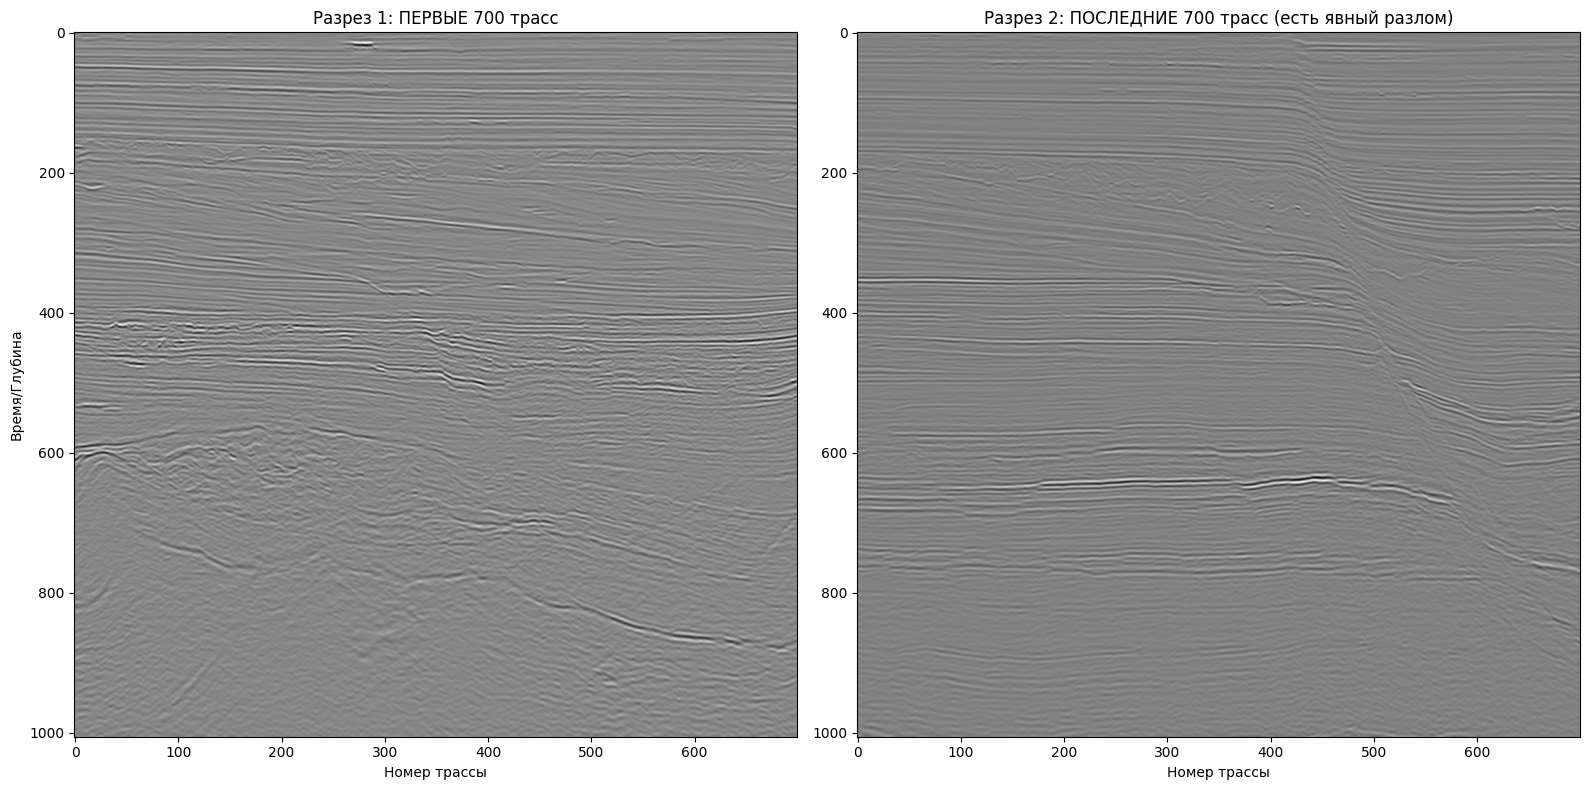

In [24]:
with segyio.open(file_path, "r", ignore_geometry=True) as segyfile:
    n_traces_total = len(segyfile.trace)
    n_samples = segyfile.trace[0].size
    print(f"Всего трасс в файле: {n_traces_total}")
    print(f"Отсчетов по времени: {n_samples}")

    # Загружаем ПЕРВЫЕ 700 трасс
    n_traces_first = min(700, n_traces_total)
    seismic_first = np.zeros((n_samples, n_traces_first))
    for i in range(n_traces_first):
        seismic_first[:, i] = segyfile.trace[i][:n_samples]

    # Загружаем ПОСЛЕДНИЕ 700 трасс
    n_traces_last = min(700, n_traces_total)
    start_trace = n_traces_total - n_traces_last
    seismic_last = np.zeros((n_samples, n_traces_last))
    for i in range(n_traces_last):
        trace_idx = start_trace + i
        seismic_last[:, i] = segyfile.trace[trace_idx][:n_samples]

# Нормализуем
seismic_first_norm = seismic_first / np.max(np.abs(seismic_first))
seismic_last_norm = seismic_last / np.max(np.abs(seismic_last))

print(f"\n✅ Первые 700 трасс: {seismic_first_norm.shape}")
print(f"✅ Последние 700 трасс: {seismic_last_norm.shape}")

# Показываем оба разреза
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.imshow(seismic_first_norm, cmap='gray', aspect='auto')
ax1.set_title("Разрез 1: ПЕРВЫЕ 700 трасс")
ax1.set_xlabel("Номер трассы")
ax1.set_ylabel("Время/Глубина")

ax2.imshow(seismic_last_norm, cmap='gray', aspect='auto')
ax2.set_title("Разрез 2: ПОСЛЕДНИЕ 700 трасс (есть явный разлом)")
ax2.set_xlabel("Номер трассы")

plt.tight_layout()
plt.show()

Разрез 1 (первые 700): полный размер (1006, 700)
Разрез 2 (последние 700): полный размер (1006, 700)


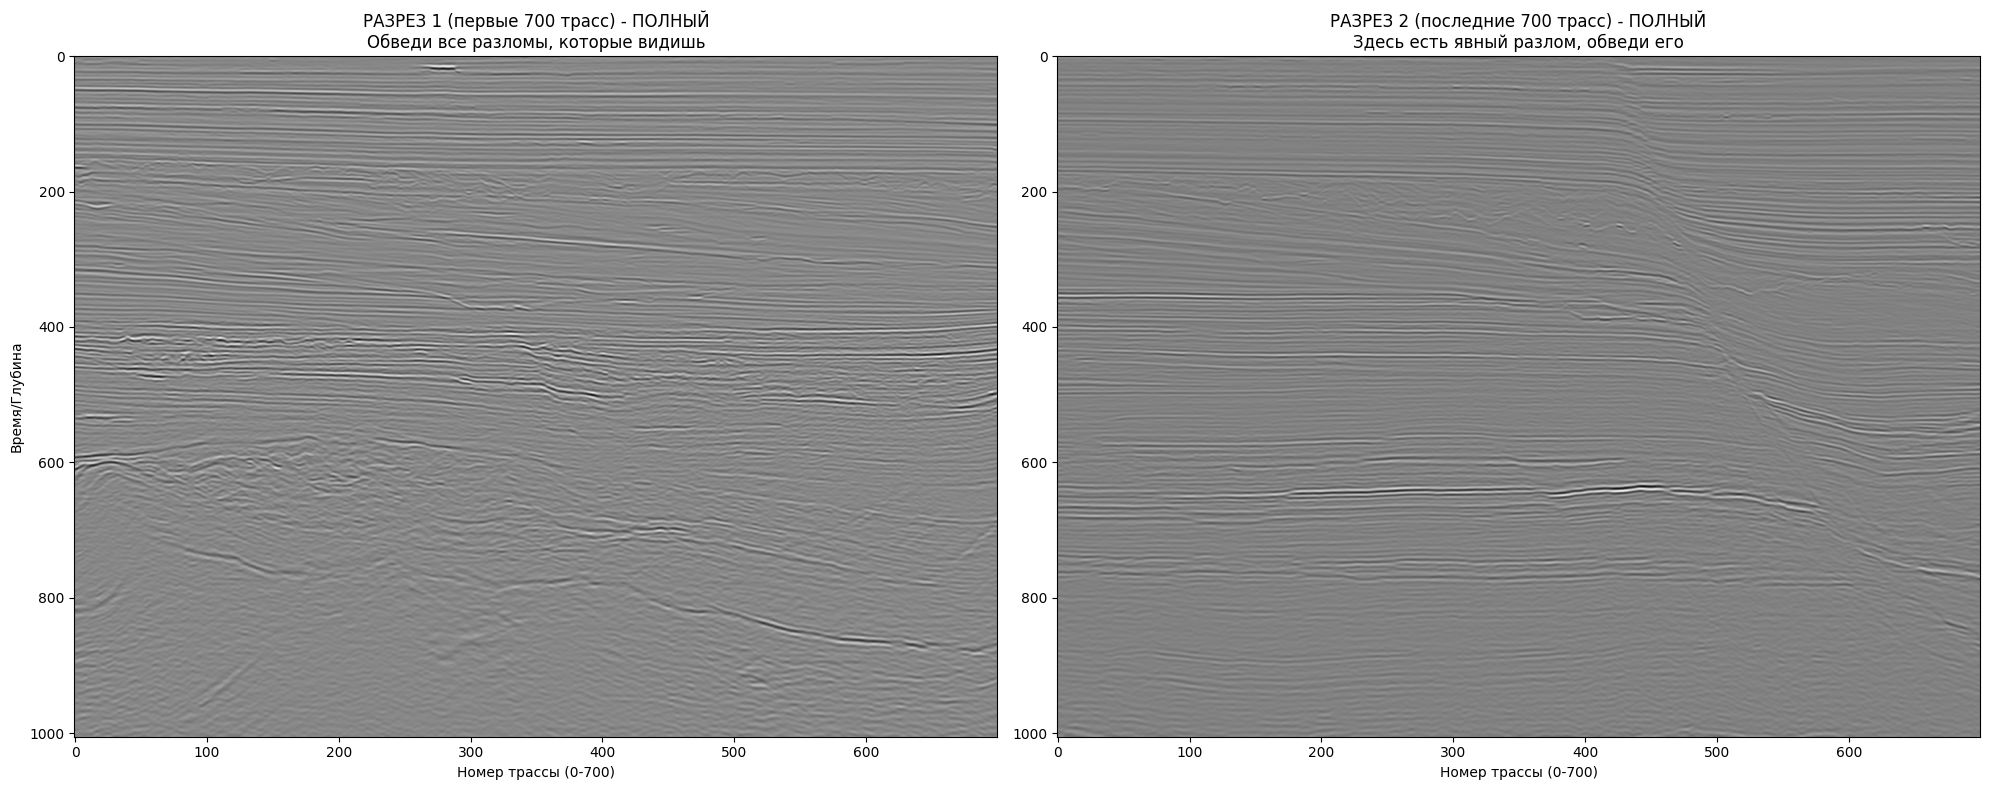


👉 ИНСТРУКЦИЯ:
1. Скачай ОБЕ картинки из Google Drive:
   - /content/drive/My Drive/seismic_section1_full.png
   - /content/drive/My Drive/seismic_section2_full.png
2. Открой в Paint
3. На КАЖДОЙ картинке обведи ВСЕ разломы, которые видишь
4. Разломы могут быть: вертикальные, наклонные, маленькие
5. Сохрани и загрузи в следующей ячейке


In [29]:
# Берем ПОЛНЫЕ разрезы (все 700 трасс)
seismic1_full = seismic_first_norm  # весь первый разрез
seismic2_full = seismic_last_norm   # весь второй разрез

print(f"Разрез 1 (первые 700): полный размер {seismic1_full.shape}")
print(f"Разрез 2 (последние 700): полный размер {seismic2_full.shape}")

# Сохраняем полные картинки
img1_data = (seismic1_full * 255).astype(np.uint8)
img1 = Image.fromarray(img1_data, mode='L')
img1.save('/content/drive/My Drive/seismic_section1_full.png')

img2_data = (seismic2_full * 255).astype(np.uint8)
img2 = Image.fromarray(img2_data, mode='L')
img2.save('/content/drive/My Drive/seismic_section2_full.png')

# Показываем полные разрезы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.imshow(seismic1_full, cmap='gray', aspect='auto')
ax1.set_title("РАЗРЕЗ 1 (первые 700 трасс) - ПОЛНЫЙ\nОбведи все разломы, которые видишь")
ax1.set_xlabel("Номер трассы (0-700)")
ax1.set_ylabel("Время/Глубина")

ax2.imshow(seismic2_full, cmap='gray', aspect='auto')
ax2.set_title("РАЗРЕЗ 2 (последние 700 трасс) - ПОЛНЫЙ\nЗдесь есть явный разлом, обведи его")
ax2.set_xlabel("Номер трассы (0-700)")

plt.tight_layout()
plt.show()

print("\n👉 ИНСТРУКЦИЯ:")
print("1. Скачай ОБЕ картинки из Google Drive:")
print("   - /content/drive/My Drive/seismic_section1_full.png")
print("   - /content/drive/My Drive/seismic_section2_full.png")
print("2. Открой в Paint")
print("3. На КАЖДОЙ картинке обведи ВСЕ разломы, которые видишь")
print("4. Разломы могут быть: вертикальные, наклонные, маленькие")
print("5. Сохрани и загрузи в следующей ячейке")


ЗАГРУЗКА: Разрез 1 (первые 700)


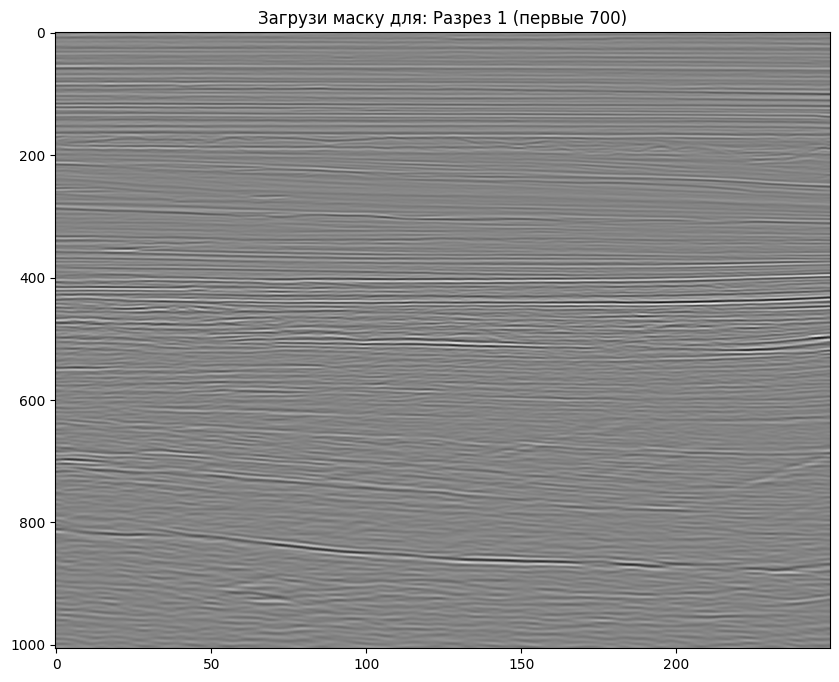

Загрузи файл PNG с разметкой:


KeyboardInterrupt: 

In [26]:
# Список для хранения масок и сейсмики
all_sections = []
all_masks = []
section_names = ["Разрез 1 (первые 700)", "Разрез 2 (последние 700)"]
section_data = [seismic1_for_labeling, seismic2_for_labeling]

for idx, (name, seismic) in enumerate(zip(section_names, section_data)):
    print(f"\n{'='*50}")
    print(f"ЗАГРУЗКА: {name}")
    print('='*50)

    # Показываем текущий разрез
    plt.figure(figsize=(10, 8))
    plt.imshow(seismic, cmap='gray', aspect='auto')
    plt.title(f"Загрузи маску для: {name}")
    plt.show()

    print("Загрузи файл PNG с разметкой:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # Загружаем маску
    mask_img = Image.open(filename).convert('L')
    mask = np.array(mask_img)
    mask_binary = (mask > 100).astype(np.uint8)

    # Приводим к размеру
    if mask_binary.shape != seismic.shape:
        mask_binary = cv2.resize(mask_binary, (seismic.shape[1], seismic.shape[0]),
                                 interpolation=cv2.INTER_NEAREST)

    all_sections.append(seismic)
    all_masks.append(mask_binary)

    print(f"✅ Загружено! Разломов отмечено: {np.sum(mask_binary)} пикселей")

    # Показываем результат
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(seismic, cmap='gray', aspect='auto')
    ax1.set_title(f"{name} - исходный")
    ax2.imshow(seismic, cmap='gray', aspect='auto')
    ax2.imshow(mask_binary, cmap='hot', alpha=0.5, aspect='auto')
    ax2.set_title(f"{name} - с разметкой")
    plt.show()

print(f"\n{'='*50}")
print(f"✅ ВСЕГО ЗАГРУЖЕНО: {len(all_sections)} разрезов")
for i, mask in enumerate(all_masks):
    print(f"  Разрез {i}: {np.sum(mask)} пикселей разломов")